<a href="https://colab.research.google.com/github/rrushaa/Customer-Segmentation-and-Recommendation-System/blob/main/ML_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

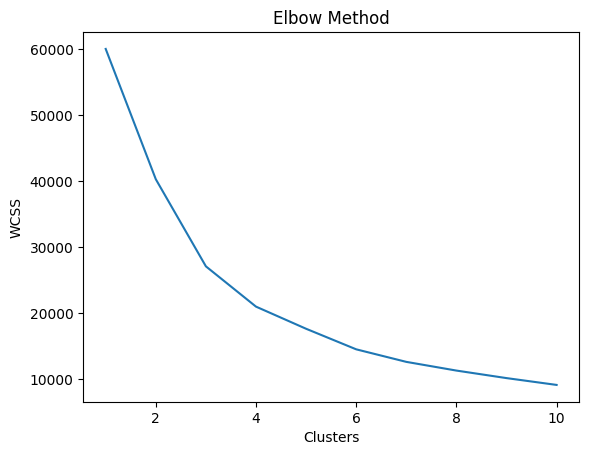

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   52                  60                      47   
1           2  Female   35                  20                      43   
2           3    Male   27                  54                      59   
3           4    Male   36                  45                     100   
4           5    Male   29                  15                      60   
5           6  Female   29                  56                      54   
6           7    Male   39                  86                      51   
7           8    Male   19                  57                      83   
8           9    Male   21                  78                      61   
9          10  Female   35                  60                      67   

  Favorite_Color Preferred_Device       City  Last_Login_Days  Cluster  \
0          Black           Tablet      Delhi               91        0   
1          Black           Mobile    

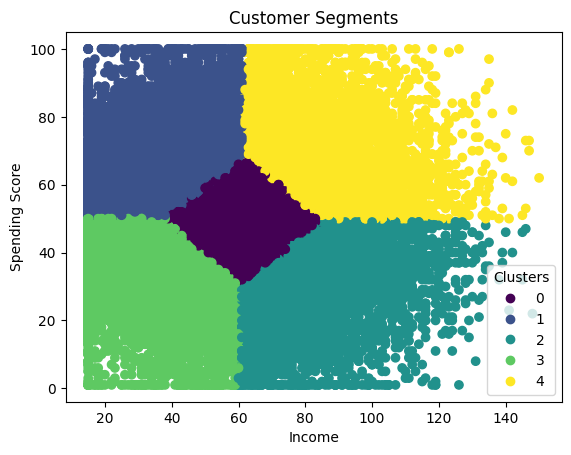

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 61.434841               49.275040
1                 38.109803               68.899109
2                 84.668951               30.343994
3                 37.065411               31.289897
4                 84.762654               69.200108
Customer Cluster: 3
Recommendations: ['Basic products, heavy discounts, and entry-level offers to increase engagement']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_excel("/content/Mall_30k..xlsx")

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_labels = {
    0: "Regular Customers (MI+MS)",
    1: "Deal Lovers (LI+HS)",
    2: "Careful High-Income Customers (HI+LS)",
    3: "Low Engagement Customers (LI+LS)",
    4: "VIP Customers (HI+HS)"
}

df['Customer_Type'] = df['Cluster'].map(cluster_labels)
print(df.head(10))


scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

# Cluster analysis
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())
df['Customer_Type'] = df['Cluster'].map(cluster_labels)


# Recommendation function
def recommend_products(cluster):

    # Medium income, medium spending
    if cluster == 0:
        return ["Balanced offers: mid-range products, combo deals, and seasonal discounts"]

    # Low income, high spending (impulsive buyers)
    elif cluster == 1:
        return ["Trendy, affordable products with discounts and limited-time offers"]

    # High income, low spending (careful rich customers)
    elif cluster == 2:
        return ["Premium products with strong value, quality assurance, and long-term benefits"]

    # Low income, low spending (low engagement)
    elif cluster == 3:
        return ["Basic products, heavy discounts, and entry-level offers to increase engagement"]

    # High income, high spending (VIP customers)
    elif cluster == 4:
        return ["Luxury products, exclusive memberships, premium deals, and personalized recommendations"]

    else:
        return ["Popular and trending products"]



customer_id = 179
cluster = df.loc[customer_id, 'Cluster']
print("Customer Cluster:", cluster)
print("Recommendations:", recommend_products(cluster))